# Exploración y Análisis de Datos con yfinance (OHLCV)  
Este notebook descarga datos desde **Yahoo Finance** usando `yfinance` y realiza un análisis exploratorio completo con **tablas y gráficas**.

**Qué incluye**
- Descarga de datos (acciones/ETFs/índices) y guardado en CSV (opcional)
- Revisión de estructura, tipos, valores nulos, duplicados
- Estadísticos descriptivos
- Rendimientos (simple y log), volatilidad rolling
- Drawdowns y métricas básicas de riesgo
- Comparación multi-activo y correlaciones
- Análisis de volumen
- Detección visual de cambios de régimen (rolling stats)

> Recomendación TFM: usa este notebook como “base de exploración” y luego migra funciones a `src/`.


## 0) Setup

In [1]:
# Si ejecutas en Colab, descomenta:
# !uv pip install -r requirements.txt

from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Carpetas (ajusta si tu repo tiene otra estructura)
DATA_RAW = Path("../data/raw")
DATA_RAW.mkdir(parents=True, exist_ok=True)

print("OK - Librerías cargadas")

OK - Librerías cargadas


## 1) Configuración: tickers y rango temporal

In [2]:
# Tickers típicos para TFM:
# SPY = S&P500 ETF, QQQ = Nasdaq100 ETF, ^VIX = volatilidad, ^GSPC = índice S&P500
TICKERS = ["SPY", "QQQ", "^GSPC", "^VIX"]
START = "2000-01-01"
END = None  # None = hasta hoy

INTERVAL = "1d"  # '1d', '1wk', '1mo' (intradía depende de limitaciones de Yahoo)

print("Tickers:", TICKERS)
print("Start:", START, "End:", END, "Interval:", INTERVAL)


Tickers: ['SPY', 'QQQ', '^GSPC', '^VIX']
Start: 2000-01-01 End: None Interval: 1d


## 2) Descarga de datos (OHLCV)

In [4]:
# Descarga multi-ticker.
# group_by='ticker' devuelve columnas por ticker cuando hay múltiples símbolos.
raw = yf.download(
    tickers=TICKERS,
    start=START,
    end=END,
    interval=INTERVAL,
    group_by="ticker",
    auto_adjust=False,
    threads=True
)

raw.tail(10)


[*********************100%***********************]  4 of 4 completed


Ticker           ^VIX                                                           ^GSPC                            \
Price            Open       High        Low      Close  Adj Close Volume         Open         High          Low   
Date                                                                                                              
2026-02-18  19.780001  20.340000  18.480000  19.620001  19.620001      0  6855.479980  6909.120117  6849.660156   
2026-02-19  19.340000  21.110001  19.230000  20.230000  20.230000      0  6861.339844  6879.120117  6833.060059   
2026-02-20  20.040001  21.209999  18.760000  19.090000  19.090000      0  6843.259766  6915.859863  6836.330078   
2026-02-23  20.490000  22.040001  19.500000  21.010000  21.010000      0  6901.250000  6916.959961  6819.819824   
2026-02-24  21.240000  22.080000  19.230000  19.549999  19.549999      0  6837.370117  6899.169922  6815.430176   
2026-02-25  19.590000  19.620001  17.860001  17.930000  17.930000      0  6915.149902  6952.509766  6915.149902   
2026-02-26  18.070000  20.540001  17.500000  18.629999  18.629999      0  6944.740234  6947.250000  6859.729980   
2026-02-27  19.280001  21.740000  18.770000  19.860001  19.860001      0  6856.540039  6882.959961  6831.740234   
2026-03-02  24.660000  25.240000  20.370001  21.440001  21.440001      0  6824.359863  6901.009766  6796.850098   
2026-03-03  24.570000  28.150000  23.910000  24.389999  24.389999      0          NaN          NaN          NaN   

Ticker                                                     SPY                                                  \
Price             Close    Adj Close        Volume        Open        High         Low       Close   Adj Close   
Date                                                                                                             
2026-02-18  6881.310059  6881.310059  5.098160e+09  684.020020  689.150024  682.830017  686.289978  686.289978   
2026-02-19  6861.890137  6861.890137  5.151690e+09  683.840027  686.179993  681.549988  684.479980  684.479980   
2026-02-20  6909.509766  6909.509766  5.432480e+09  682.320007  690.059998  681.729980  689.429993  689.429993   
2026-02-23  6837.750000  6837.750000  5.638350e+09  687.830017  690.000000  680.369995  682.390015  682.390015   
2026-02-24  6890.069824  6890.069824  5.266090e+09  681.900024  688.349976  680.000000  687.349976  687.349976   
2026-02-25  6946.129883  6946.129883  5.328060e+09  690.179993  693.679993  690.099976  693.150024  693.150024   
2026-02-26  6908.859863  6908.859863  5.889550e+09  693.280029  693.299988  684.349976  689.299988  689.299988   
2026-02-27  6878.879883  6878.879883  6.665660e+09  683.090027  686.859985  681.640015  685.989990  685.989990   
2026-03-02  6881.620117  6881.620117  6.079080e+09  678.700012  688.619995  678.020020  686.380005  686.380005   
2026-03-03          NaN          NaN           NaN         NaN         NaN         NaN         NaN         NaN   

Ticker                          QQQ                                                              
Price            Volume        Open        High         Low       Close   Adj Close      Volume  
Date                                                                                             
2026-02-18   73570300.0  602.109985  609.770020  600.719971  605.789978  605.789978  64250700.0  
2026-02-19   58649400.0  602.809998  605.820007  600.750000  603.469971  603.469971  60960800.0  
2026-02-20  100034000.0  600.119995  610.349976  599.229980  608.809998  608.809998  74127300.0  
2026-02-23   90558100.0  606.609985  608.010010  599.049988  601.409973  601.409973  63859100.0  
2026-02-24   73798700.0  602.400024  608.989990  599.729980  607.869995  607.869995  55023700.0  
2026-02-25   56369500.0  611.070007  616.830017  611.000000  616.679993  616.679993  55710700.0  
2026-02-26   71671000.0  615.590027  615.590027  603.979980  609.239990  609.239990  96178900.0  
2026-02-27   83308900.0  602.979980  608.

### 2.1) Guardar CSV (opcional, recomendado para reproducibilidad)

In [ ]:
# Guarda un CSV por ticker en data/raw
def save_raw_per_ticker(raw_df: pd.DataFrame, tickers: list[str], out_dir: Path, interval: str) -> None:
    if isinstance(raw_df.columns, pd.MultiIndex):
        for t in tickers:
            if t in raw_df.columns.get_level_values(0):
                df_t = raw_df[t].copy()
                df_t.to_csv(out_dir / f"{t.replace('^','')}_{interval}_raw.csv")
    else:
        raw_df.to_csv(out_dir / f"{tickers[0].replace('^','')}_{interval}_raw.csv")

save_raw_per_ticker(raw, TICKERS, DATA_RAW, INTERVAL)
print("Guardado en:", DATA_RAW.resolve())


## 3) Normalización a formato “largo” (DataFrame estándar)

In [5]:
def to_long_ohlcv(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Convierte el DataFrame de yfinance a formato largo:
    columnas: [Date, Ticker, Open, High, Low, Close, Adj_Close, Volume]
    """
    if isinstance(raw_df.columns, pd.MultiIndex):
        out = (
            raw_df
            .stack(level=0, future_stack=True)  # mueve tickers a filas
            .rename_axis(index=["Date", "Ticker"])
            .reset_index()
        )
        out.columns = [c.replace(" ", "_") for c in out.columns]
        return out
    else:
        out = raw_df.copy().reset_index()
        out["Ticker"] = "SINGLE"
        out.columns = [c.replace(" ", "_") for c in out.columns]
        return out

df_long = to_long_ohlcv(raw)
df_long.head()


,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2000-01-03,^VIX,24.360001,26.1500,23.980000,24.209999,24.209999,0.0
1,2000-01-03,^GSPC,1469.250000,1478.0000,1438.359985,1455.219971,1455.219971,931800000.0
2,2000-01-03,SPY,148.250000,148.2500,143.875000,145.437500,91.617050,8164300.0
3,2000-01-03,QQQ,96.187500,96.1875,90.750000,94.750000,80.028160,36345200.0
4,2000-01-04,^VIX,24.940001,27.1800,24.799999,27.010000,27.010000,0.0


### 3.1) Vista rápida por ticker

In [6]:
df_long.groupby('Ticker').head(3)

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2000-01-03,^VIX,24.360001,26.150000,23.980000,24.209999,24.209999,0.000000e+00
1,2000-01-03,^GSPC,1469.250000,1478.000000,1438.359985,1455.219971,1455.219971,9.318000e+08
2,2000-01-03,SPY,148.250000,148.250000,143.875000,145.437500,91.617050,8.164300e+06
3,2000-01-03,QQQ,96.187500,96.187500,90.750000,94.750000,80.028160,3.634520e+07
4,2000-01-04,^VIX,24.940001,27.180000,24.799999,27.010000,27.010000,0.000000e+00
5,2000-01-04,^GSPC,1455.219971,1455.219971,1397.430054,1399.420044,1399.420044,1.009000e+09
6,2000-01-04,SPY,143.531250,144.062500,139.640625,139.750000,88.034286,8.089800e+06
7,2000-01-04,QQQ,92.000000,93.500000,87.937500,88.250000,74.538139,3.378660e+07
8,2000-01-05,^VIX,27.980000,29.000000,25.850000,26.410000,26.410000,0.000000e+00
9,2000-01-05,^GSPC,1399.420044,1413.270020,1377.680054,1402.109985,1402.109985,1.085500e+09


## 4) Calidad de datos: nulos, duplicados, rangos, tipos

In [7]:
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True)
    })
    return rep.sort_values("pct_missing", ascending=False)

print("Filas:", len(df_long), "Columnas:", df_long.shape[1])
print("Duplicados (filas completas):", df_long.duplicated().sum())

quality = data_quality_report(df_long)
quality


Filas: 26320 Columnas: 8
Duplicados (filas completas): 0


,dtype,n_missing,pct_missing,n_unique
High,float64,3,0.01,18968
Open,float64,3,0.01,18975
Close,float64,3,0.01,19007
Low,float64,3,0.01,18896
Adj_Close,float64,3,0.01,21410
Volume,float64,3,0.01,19524
Date,datetime64[ns],0,0.00,6580
Ticker,object,0,0.00,4


## 5) Estadísticos descriptivos por ticker

In [8]:
numeric_cols = [c for c in df_long.columns if c not in ["Date", "Ticker"]]

desc = (
    df_long
    .groupby("Ticker")[numeric_cols]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

desc


Open                                                                                                       \
         count         mean          std         min          1%          5%          50%          95%          99%   
Ticker                                                                                                                
QQQ     6579.0   147.482557   148.003863   19.940001   24.059999   29.709999    82.875000   484.856998   610.875007   
SPY     6579.0   229.517239   148.775470   67.949997   83.095599   91.999000   153.740005   563.838989   679.702822   
^GSPC   6579.0  2296.832221  1493.678958  679.280029  829.601997  918.110004  1539.290039  5647.680908  6812.957656   
^VIX    6580.0    19.973973     8.407454    9.010000   10.040000   11.410000    17.889999    34.600499    52.531500   

                       High                                                                                          \
                max   count         mean          std         min          1%          5%          50%          95%   
Ticker                                                                                                                
QQQ      635.590027  6579.0   148.617291   148.962353   20.530001   24.500000   30.250000    83.312500   487.181995   
SPY      697.049988  6579.0   230.836740   149.455368   70.000000   84.342400   93.177000   154.520004   567.588000   
^GSPC   7002.000000  6579.0  2309.880965  1500.497265  695.270020  841.106206  927.935992  1545.250000  5692.051953   
^VIX      82.690002  6580.0    20.880903     8.990620    9.310000   10.410000   11.799500    18.700001    36.400002   

                                     Low                                                    ...       Close  \
                99%          max   count         mean          std         min          1%  ...          5%   
Ticker                                                                                      ...               
QQQ      613.540813   637.010010  6579.0   146.220747   146.909841   19.760000   23.665600  ...   29.698001   
SPY      683.117594   697.840027  6579.0   228.072267   148.014201   67.099998   81.843399  ...   92.119003   
^GSPC   6845.236094  7002.279785  6579.0  2282.757381  1486.264342  666.789978  817.203795  ...  918.354993   
^VIX      56.908200    89.529999  6580.0    19.061767     7.800340    8.560000    9.717900  ...   11.349500   

                                                           Adj_Close                                        \
                50%          95%          99%          max     count         mean          std         min   
Ticker                                                                                                       
QQQ       82.625000   483.903006   609.669817   635.770020    6579.0   140.817301   148.611513   16.943172   
SPY      153.970001   564.358026   679.926818   695.489990    6579.0   199.506013   157.287328   49.944588   
^GSPC   1539.589966  5662.995117  6813.483457  6978.600098    6579.0  2297.175868  1493.966163  676.530029   
^VIX      17.780001    34.441499    52.717201    82.690002    6580.0    19.825625     8.344505    9.140000   

                                                                                    Volume                \
                1%          5%          50%          95%          99%          max   count          mean   
Ticker                                                                                                     
QQQ      20.378097   25.370200    72.426567   480.553201   609.330198   634.951965  6579.0  6.655465e+07   
SPY      55.799057   63.997874   119.810738   558.944891   677.923606   695.489990  6579.0  1.046756e+08   
^GSPC   829.814781  918.354993  1539.589966  5662.995117  6813.483457  6978.600098  6579.0  3.432220e+09   
^VIX     10.027900   11.349500    17.780001    34.441499    52.717201    82.690002  6580.0  0.000000e+00   

                                    

## 6) Visualización: precio y volumen

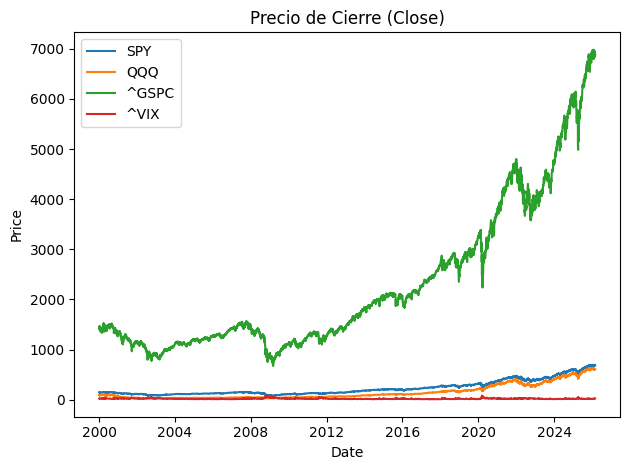

In [9]:
def plot_close_prices(raw_df: pd.DataFrame, tickers: list[str], title: str = "Close Price"):
    plt.figure()
    if isinstance(raw_df.columns, pd.MultiIndex):
        for t in tickers:
            if (t, "Close") in raw_df.columns:
                plt.plot(raw_df.index, raw_df[(t, "Close")], label=t)
    else:
        plt.plot(raw_df.index, raw_df["Close"], label=tickers[0])
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_close_prices(raw, TICKERS, "Precio de Cierre (Close)")


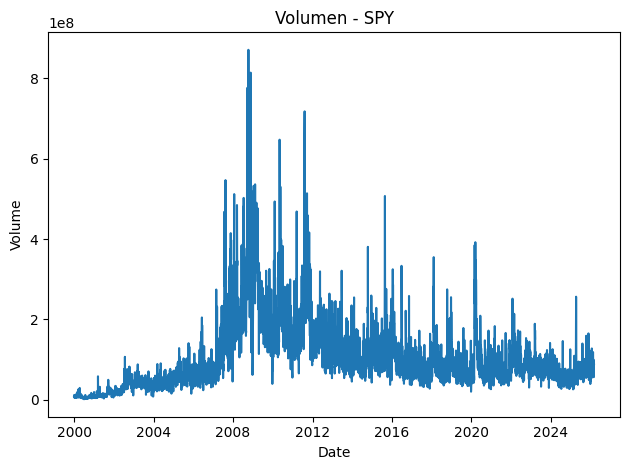

In [10]:
def plot_volume(raw_df: pd.DataFrame, ticker: str):
    plt.figure()
    if isinstance(raw_df.columns, pd.MultiIndex):
        vol = raw_df[(ticker, "Volume")]
        plt.plot(raw_df.index, vol)
        plt.title(f"Volumen - {ticker}")
    else:
        plt.plot(raw_df.index, raw_df["Volume"])
        plt.title(f"Volumen - {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.tight_layout()
    plt.show()

plot_volume(raw, "SPY")


## 7) Rendimientos y volatilidad (base para HMM / Change Point / LSTM)

In [11]:
def get_close_wide(raw_df: pd.DataFrame, tickers: list[str]) -> pd.DataFrame:
    if isinstance(raw_df.columns, pd.MultiIndex):
        close = pd.DataFrame({t: raw_df[(t, "Close")] for t in tickers if (t, "Close") in raw_df.columns})
    else:
        close = raw_df[["Close"]].rename(columns={"Close": tickers[0]})
    return close

close = get_close_wide(raw, TICKERS)
close.tail()


,SPY,QQQ,^GSPC,^VIX
Date,,,,
2026-02-25,693.150024,616.679993,6946.129883,17.930000
2026-02-26,689.299988,609.239990,6908.859863,18.629999
2026-02-27,685.989990,607.289978,6878.879883,19.860001
2026-03-02,686.380005,608.090027,6881.620117,21.440001
2026-03-03,NaN,NaN,NaN,24.389999


In [12]:
# Rendimientos
ret = close.pct_change()
logret = np.log(close).diff()

# Volatilidad rolling (anualizada aproximada para daily)
ROLL = 21  # ~1 mes bursátil
vol = logret.rolling(ROLL).std() * np.sqrt(252)

ret.describe().T


C:\Users\usuario\AppData\Local\Temp\ipykernel_11644\895960192.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = close.pct_change()


,count,mean,std,min,25%,50%,75%,max
SPY,6579.0,0.000310,0.012215,-0.109424,-0.004789,0.000628,0.005959,0.145198
QQQ,6579.0,0.000425,0.016904,-0.119788,-0.006513,0.001077,0.007948,0.168421
^GSPC,6579.0,0.000310,0.012174,-0.119841,-0.004724,0.000634,0.005878,0.115800
^VIX,6579.0,0.002640,0.075330,-0.357539,-0.039055,-0.005335,0.034127,1.155979


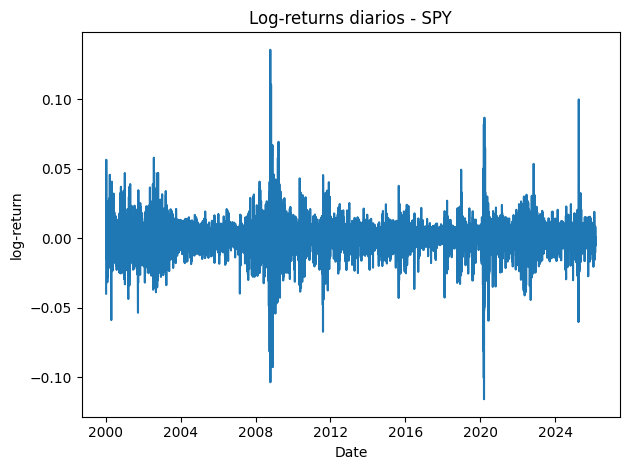

In [13]:
# Gráfica de log-returns (una serie)
ticker_focus = "SPY"
plt.figure()
plt.plot(logret.index, logret[ticker_focus])
plt.title(f"Log-returns diarios - {ticker_focus}")
plt.xlabel("Date")
plt.ylabel("log-return")
plt.tight_layout()
plt.show()


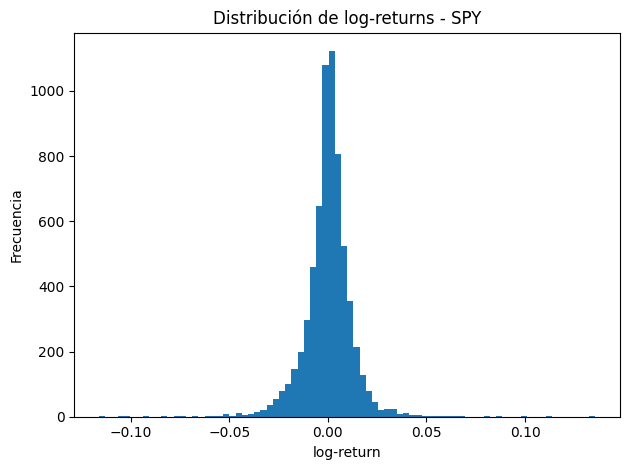

mean         0.000236
std          0.012220
skew        -0.206397
kurtosis    11.471052
dtype: float64

In [14]:
# Histograma de returns + momentos
plt.figure()
vals = logret[ticker_focus].dropna().values
plt.hist(vals, bins=80)
plt.title(f"Distribución de log-returns - {ticker_focus}")
plt.xlabel("log-return")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

moments = pd.Series({
    "mean": np.mean(vals),
    "std": np.std(vals),
    "skew": pd.Series(vals).skew(),
    "kurtosis": pd.Series(vals).kurtosis()
})
moments


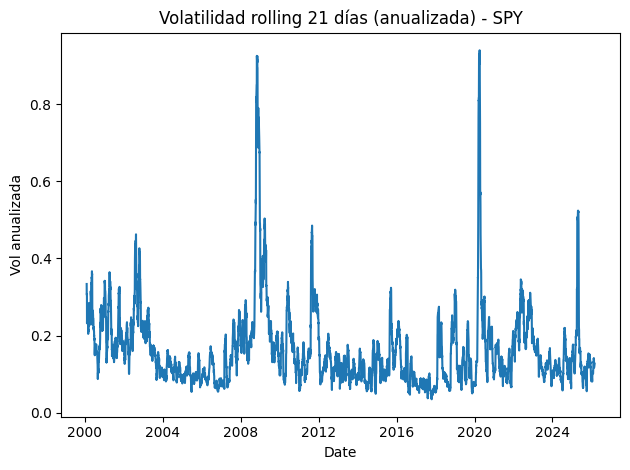

In [15]:
# Volatilidad rolling
plt.figure()
plt.plot(vol.index, vol[ticker_focus])
plt.title(f"Volatilidad rolling {ROLL} días (anualizada) - {ticker_focus}")
plt.xlabel("Date")
plt.ylabel("Vol anualizada")
plt.tight_layout()
plt.show()


## 8) Drawdown (crisis 2008, COVID, etc.)

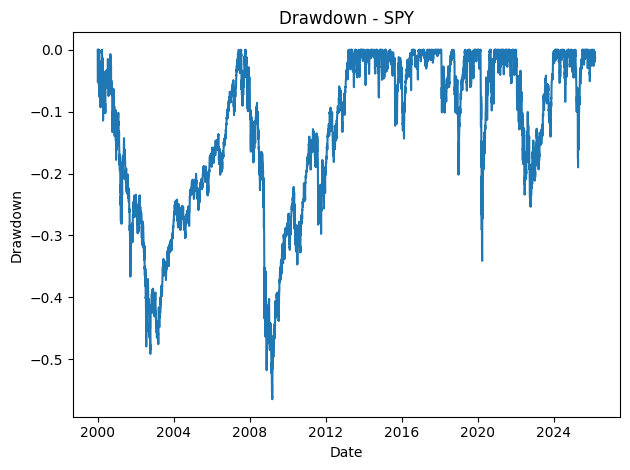

count    6579.000000
mean       -0.130063
std         0.128636
min        -0.564737
25%        -0.217582
50%        -0.088318
75%        -0.015591
max         0.000000
Name: drawdown, dtype: float64

In [16]:
def compute_drawdown(price: pd.Series) -> pd.DataFrame:
    cummax = price.cummax()
    dd = price / cummax - 1.0
    return pd.DataFrame({"price": price, "cummax": cummax, "drawdown": dd})

dd = compute_drawdown(close[ticker_focus].dropna())

plt.figure()
plt.plot(dd.index, dd["drawdown"])
plt.title(f"Drawdown - {ticker_focus}")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()

dd["drawdown"].describe()


## 9) Comparación multi-activo: correlaciones

In [17]:
corr = logret.dropna().corr()
corr


,SPY,QQQ,^GSPC,^VIX
SPY,1.000000,0.854990,0.986540,-0.728408
QQQ,0.854990,1.000000,0.847982,-0.624052
^GSPC,0.986540,0.847982,1.000000,-0.732049
^VIX,-0.728408,-0.624052,-0.732049,1.000000


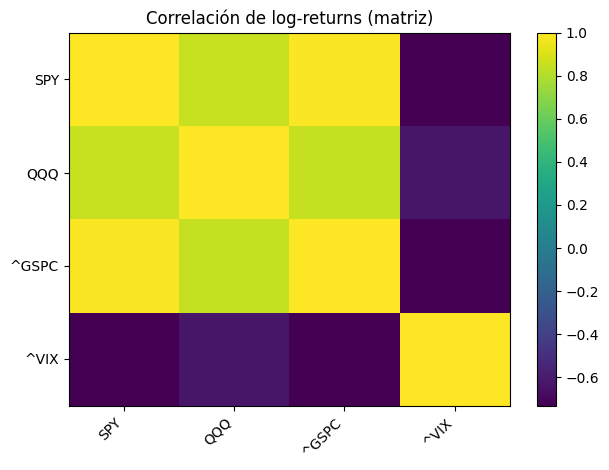

In [18]:
# Heatmap simple con matplotlib (sin seaborn)
plt.figure()
plt.imshow(corr.values, aspect="auto")
plt.title("Correlación de log-returns (matriz)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()


## 10) Señales simples de tendencia (MA crossover)

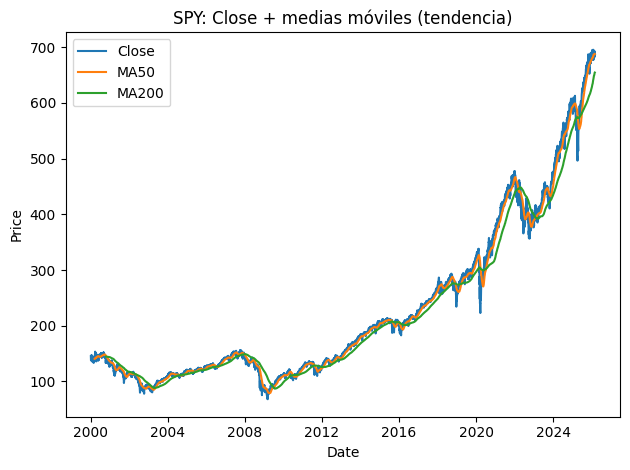

SPY
1    4508
0    2072
Name: count, dtype: int64

In [19]:
SHORT = 50
LONG = 200

ma_s = close[ticker_focus].rolling(SHORT).mean()
ma_l = close[ticker_focus].rolling(LONG).mean()
signal = (ma_s > ma_l).astype(int)

plt.figure()
plt.plot(close.index, close[ticker_focus], label="Close")
plt.plot(ma_s.index, ma_s, label=f"MA{SHORT}")
plt.plot(ma_l.index, ma_l, label=f"MA{LONG}")
plt.title(f"{ticker_focus}: Close + medias móviles (tendencia)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

signal.value_counts()


## 11) Tabla resumen final (por ticker)

In [20]:
summary_rows = []
for t in close.columns:
    s = close[t].dropna()
    if len(s) < 300:
        continue
    lr = np.log(s).diff().dropna()
    ann_ret = lr.mean() * 252
    ann_vol = lr.std() * np.sqrt(252)
    max_dd = compute_drawdown(s)["drawdown"].min()
    summary_rows.append({
        "Ticker": t,
        "start": s.index.min().date(),
        "end": s.index.max().date(),
        "n_obs": len(s),
        "ann_log_return": float(ann_ret),
        "ann_vol": float(ann_vol),
        "max_drawdown": float(max_dd),
    })

summary = pd.DataFrame(summary_rows).set_index("Ticker").sort_index()
summary


,start,end,n_obs,ann_log_return,ann_vol,max_drawdown
Ticker,,,,,,
QQQ,2000-01-03,2026-03-02,6579,0.071220,0.268050,-0.829639
SPY,2000-01-03,2026-03-02,6579,0.059444,0.193995,-0.564737
^GSPC,2000-01-03,2026-03-02,6579,0.059521,0.193529,-0.567754
^VIX,2000-01-03,2026-03-03,6580,0.000284,1.137136,-0.886965


## 12) Siguientes pasos (para tu TFM)
- Guardar `close`, `logret`, `vol` en `data/processed/`
- Implementar **HMM** sobre `logret['SPY']` y contrastar estados con crisis
- Implementar **Change Point Detection** sobre `logret` o `vol`
- Más adelante: integrar macro (FRED) y sentimiento (FinBERT)
